In [1]:
# 安装本次任务需要的库
!pip install PyGithub boto3 tensorflow pandas scikit-learn seaborn matplotlib -q


# =========================
# 1. 导入 Python 库
# =========================

import io
import os
import random
import boto3
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from datetime import datetime
from getpass import getpass
from github import Github, Auth, GithubException

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping


# =========================
# 2. 固定随机种子
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================
# 3. 文件配置
# =========================

DATA_FILENAME = "titanic_clean.csv"

MODEL_3_FILENAME = "model_3_layers.h5"
MODEL_5_FILENAME = "model_5_layers.h5"

README_FILENAME = "README.md"
NOTEBOOK_FILENAME = "titanic_dl_pipeline.ipynb"


# =========================
# 4. GitHub 配置
# =========================

REPO_NAME = "ZhangHui88888/mds7-Hui-Zhang"

# Week 3–4 已经清洗完成的数据
SOURCE_DATA_PATH = (
    "week-03-04-powerbi/"
    "titanic_clean.csv"
)

# 本次深度学习作业的目标目录
TARGET_FOLDER = (
    "week-05-06-bigquery/"
    "deeplearning"
)


# =========================
# 5. AWS S3 配置
# =========================

REGION_NAME = "eu-north-1"
BUCKET_NAME = "mds7-hui-zhang-titanic"
S3_PREFIX = "deeplearning"


# =========================
# 6. 安全输入凭证
# =========================

# 输入内容不会显示或保存在 Notebook 中
AWS_ACCESS_KEY_ID = getpass("Enter AWS Access Key ID: ")
AWS_SECRET_ACCESS_KEY = getpass("Enter AWS Secret Access Key: ")
GITHUB_TOKEN = getpass("Enter GitHub Personal Access Token: ")

# =========================
# 7. 创建 AWS S3 客户端
# =========================

s3_client = boto3.client(
    "s3",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=REGION_NAME
)


# =========================
# 8. 创建 GitHub 客户端
# =========================

github_auth = Auth.Token(GITHUB_TOKEN)
github_client = Github(auth=github_auth)

repo = github_client.get_repo(REPO_NAME)
TARGET_BRANCH = repo.default_branch


# =========================
# 9. 检查 TensorFlow 环境
# =========================

print("TensorFlow version:", tf.__version__)
print(
    "GPU devices:",
    tf.config.list_physical_devices("GPU")
)


# =========================
# 10. 输出环境信息
# =========================

print("\nEnvironment setup complete.")
print("Repository:", REPO_NAME)
print("Branch:", TARGET_BRANCH)
print("Source data:", SOURCE_DATA_PATH)
print("Target folder:", TARGET_FOLDER)
print("S3 destination:", f"s3://{BUCKET_NAME}/{S3_PREFIX}/")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.3 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU devices: []

Environment setup complete.
Repository: ZhangHui88888/mds7-Hui-Zhang
Branch: main
Source data: week-03-04-powerbi/titanic_clean.csv
Target folder: week-05-06-bigquery/deeplearning
S3 destination: s3://mds7-hui-zhang-titanic/deeplearning/


In [2]:
# =========================
# 2. 从 GitHub 拉取 clean data
# =========================

print("Downloading Titanic clean data from GitHub...")


# 从仓库默认分支获取 CSV
github_data_file = repo.get_contents(
    SOURCE_DATA_PATH,
    ref=TARGET_BRANCH
)


# 解码 GitHub 文件内容
csv_content = (
    github_data_file
    .decoded_content
    .decode("utf-8")
)


# 保存到 Colab 当前目录
with open(
    DATA_FILENAME,
    "w",
    encoding="utf-8"
) as local_csv:
    local_csv.write(csv_content)


# 使用 Pandas 读取
df = pd.read_csv(DATA_FILENAME)


# =========================
# 验证数据来源和内容
# =========================

print("Download complete.")
print(
    f"GitHub source: "
    f"{REPO_NAME}/{SOURCE_DATA_PATH}"
)

print("Local file:", DATA_FILENAME)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

Download complete.
GitHub source: ZhangHui88888/mds7-Hui-Zhang/week-03-04-powerbi/titanic_clean.csv
Local file: titanic_clean.csv
Rows: 891
Columns: 12

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

First five rows:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


In [4]:
# =========================
# 3. 数据预处理与数据集划分
# =========================

TARGET_COLUMN = "Survived"

# 删除文本和唯一标识字段
COLUMNS_TO_DROP = [
    "PassengerId",
    "Name",
    "Ticket"
]


# -------------------------
# 3.1 检查数据质量
# -------------------------

print("Missing values:")
print(df.isna().sum())

print("\nDuplicated rows:", df.duplicated().sum())


# -------------------------
# 3.2 创建特征 X 和目标 y
# -------------------------

X = df.drop(
    columns=[TARGET_COLUMN] + COLUMNS_TO_DROP
)

y = df[TARGET_COLUMN].astype("int32")


# 只保留数值字段
X = X.select_dtypes(include=[np.number])

feature_names = X.columns.tolist()


print("\nSelected features:")
print(feature_names)

print("\nNumber of features:", len(feature_names))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget percentage:")
print(
    y.value_counts(
        normalize=True
    ).sort_index()
)


# -------------------------
# 3.3 划分测试集
# -------------------------

X_remaining, X_test, y_remaining, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=SEED,
        stratify=y
    )
)


# -------------------------
# 3.4 划分训练集和验证集
# -------------------------

X_train, X_validation, y_train, y_validation = (
    train_test_split(
        X_remaining,
        y_remaining,
        test_size=0.20,
        random_state=SEED,
        stratify=y_remaining
    )
)


# -------------------------
# 3.5 标准化输入特征
# -------------------------

scaler = StandardScaler()

# 只使用训练数据拟合，防止数据泄露
X_train_scaled = scaler.fit_transform(
    X_train
)

X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)


# 转换为 TensorFlow 常用的数据类型
X_train_scaled = X_train_scaled.astype("float32")
X_validation_scaled = X_validation_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")


# 标签也转换为 NumPy float32
y_train_array = y_train.to_numpy(
    dtype="float32"
)

y_validation_array = y_validation.to_numpy(
    dtype="float32"
)

y_test_array = y_test.to_numpy(
    dtype="float32"
)


# -------------------------
# 3.6 输出最终结果
# -------------------------

print("\nData preprocessing complete.")

print("Training set:", X_train_scaled.shape)
print("Validation set:", X_validation_scaled.shape)
print("Test set:", X_test_scaled.shape)

print("\nTraining labels:", y_train_array.shape)
print("Validation labels:", y_validation_array.shape)
print("Test labels:", y_test_array.shape)

print("\nInput feature count:", X_train_scaled.shape[1])

Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64

Duplicated rows: 0

Selected features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Number of features: 8

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target percentage:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Data preprocessing complete.
Training set: (569, 8)
Validation set: (143, 8)
Test set: (179, 8)

Training labels: (569,)
Validation labels: (143,)
Test labels: (179,)

Input feature count: 8


In [5]:
# =========================
# 4. 建立三层神经网络
# =========================

model_3_layers = models.Sequential(
    [
        # 输入层不计入三层模型
        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        # 第 1 层：隐藏层
        layers.Dense(
            units=32,
            activation="relu"
        ),

        # 第 2 层：隐藏层
        layers.Dense(
            units=16,
            activation="relu"
        ),

        # 第 3 层：二分类输出层
        layers.Dense(
            units=1,
            activation="sigmoid"
        )
    ],
    name="titanic_3_layer_model"
)


# 编译模型
model_3_layers.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# 显示模型结构
print("Three-layer neural network:")
model_3_layers.summary()

Three-layer neural network:


Model: "titanic_3_layer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# =========================
# 4. 建立三层神经网络
# =========================

model_3_layers = models.Sequential(
    [
        # 输入层不计入三层模型
        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        # 第 1 层：隐藏层
        layers.Dense(
            units=32,
            activation="relu"
        ),

        # 第 2 层：隐藏层
        layers.Dense(
            units=16,
            activation="relu"
        ),

        # 第 3 层：二分类输出层
        layers.Dense(
            units=1,
            activation="sigmoid"
        )
    ],
    name="titanic_3_layer_model"
)


# 编译模型
model_3_layers.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# 显示模型结构
print("Three-layer neural network:")
model_3_layers.summary()

Three-layer neural network:


Model: "titanic_3_layer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# =========================
# 5. 训练三层神经网络
# =========================

# 为三层模型单独创建 Early Stopping
early_stopping_3 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


print("Training three-layer neural network...")


history_3_layers = model_3_layers.fit(
    X_train_scaled,
    y_train_array,

    # 最多训练 100 轮
    epochs=100,

    batch_size=32,

    # 使用独立验证集
    validation_data=(
        X_validation_scaled,
        y_validation_array
    ),

    callbacks=[early_stopping_3],

    verbose=1
)

Training three-layer neural network...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5888 - loss: 0.6761 - val_accuracy: 0.7273 - val_loss: 0.6293
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7487 - loss: 0.6011 - val_accuracy: 0.7552 - val_loss: 0.5699
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7821 - loss: 0.5469 - val_accuracy: 0.7832 - val_loss: 0.5256
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7856 - loss: 0.5036 - val_accuracy: 0.7762 - val_loss: 0.4943
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7821 - loss: 0.4712 - val_accuracy: 0.7692 - val_loss: 0.4750
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7838 - loss: 0.4492 - val_accuracy: 0.7692 - val_loss: 0.4647
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7979 - loss: 0.4350 - val_accuracy: 0.7762 - val_loss: 0.4594
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.

Three-Layer Model Test Results
--------------------------------
Test Loss: 0.4614
Test Accuracy: 81.01%
Precision: 0.8571
Recall: 0.6087
F1 Score: 0.7119

Classification Report:

              precision    recall  f1-score   support

Not Survived     0.7923    0.9364    0.8583       110
    Survived     0.8571    0.6087    0.7119        69

    accuracy                         0.8101       179
   macro avg     0.8247    0.7725    0.7851       179
weighted avg     0.8173    0.8101    0.8019       179



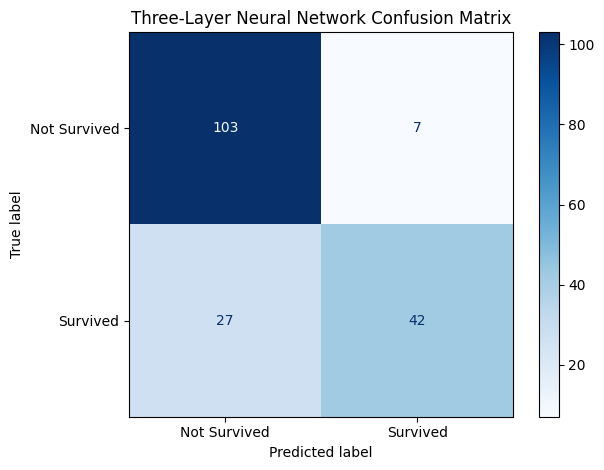

In [8]:
# =========================
# 6. 评估三层神经网络
# =========================

# 计算测试损失和测试准确率
test_loss_3, test_accuracy_3 = (
    model_3_layers.evaluate(
        X_test_scaled,
        y_test_array,
        verbose=0
    )
)


# 预测生还概率
test_probabilities_3 = (
    model_3_layers.predict(
        X_test_scaled,
        verbose=0
    ).ravel()
)


# 使用 0.5 作为分类阈值
test_predictions_3 = (
    test_probabilities_3 >= 0.5
).astype("int32")


# 转换真实标签
y_test_integer = y_test_array.astype("int32")


# 计算评估指标
precision_3 = precision_score(
    y_test_integer,
    test_predictions_3
)

recall_3 = recall_score(
    y_test_integer,
    test_predictions_3
)

f1_3 = f1_score(
    y_test_integer,
    test_predictions_3
)


# 输出结果
print("Three-Layer Model Test Results")
print("--------------------------------")

print(f"Test Loss: {test_loss_3:.4f}")
print(
    f"Test Accuracy: "
    f"{test_accuracy_3 * 100:.2f}%"
)
print(f"Precision: {precision_3:.4f}")
print(f"Recall: {recall_3:.4f}")
print(f"F1 Score: {f1_3:.4f}")


# 输出分类报告
print("\nClassification Report:\n")

print(
    classification_report(
        y_test_integer,
        test_predictions_3,
        target_names=[
            "Not Survived",
            "Survived"
        ],
        digits=4,
        zero_division=0
    )
)


# 绘制混淆矩阵
ConfusionMatrixDisplay.from_predictions(
    y_test_integer,
    test_predictions_3,
    display_labels=[
        "Not Survived",
        "Survived"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Three-Layer Neural Network Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [9]:
# =========================
# 7. 保存并验证三层模型
# =========================

# 保存 Early Stopping 恢复后的最佳模型
model_3_layers.save(
    MODEL_3_FILENAME
)

print(
    f"Three-layer model saved: "
    f"{MODEL_3_FILENAME}"
)


# 计算模型文件大小
model_3_size_mb = (
    os.path.getsize(MODEL_3_FILENAME)
    / (1024 * 1024)
)

print(
    f"Model file size: "
    f"{model_3_size_mb:.2f} MB"
)


# -------------------------
# 重新加载并验证
# -------------------------

loaded_model_3 = (
    tf.keras.models.load_model(
        MODEL_3_FILENAME
    )
)


loaded_loss_3, loaded_accuracy_3 = (
    loaded_model_3.evaluate(
        X_test_scaled,
        y_test_array,
        verbose=0
    )
)


print("\nReloaded three-layer model verification:")

print(
    f"Test Loss: "
    f"{loaded_loss_3:.4f}"
)

print(
    f"Test Accuracy: "
    f"{loaded_accuracy_3 * 100:.2f}%"
)

Three-layer model saved: model_3_layers.h5
Model file size: 0.04 MB

Reloaded three-layer model verification:
Test Loss: 0.4614
Test Accuracy: 81.01%


In [10]:
# =========================
# 8. 建立五层神经网络
# =========================

model_5_layers = models.Sequential(
    [
        # 输入层不计入五层模型
        layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        # 第 1 层：隐藏层
        layers.Dense(
            units=64,
            activation="relu"
        ),

        # 第 2 层：隐藏层
        layers.Dense(
            units=32,
            activation="relu"
        ),

        # 第 3 层：隐藏层
        layers.Dense(
            units=16,
            activation="relu"
        ),

        # 第 4 层：隐藏层
        layers.Dense(
            units=8,
            activation="relu"
        ),

        # 第 5 层：二分类输出层
        layers.Dense(
            units=1,
            activation="sigmoid"
        )
    ],
    name="titanic_5_layer_model"
)


# 编译模型
model_5_layers.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# 显示模型结构
print("Five-layer neural network:")
model_5_layers.summary()

Five-layer neural network:


Model: "titanic_5_layer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# =========================
# 9. 训练五层神经网络
# =========================

# 为五层模型单独创建 Early Stopping
early_stopping_5 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


print("Training five-layer neural network...")


history_5_layers = model_5_layers.fit(
    X_train_scaled,
    y_train_array,

    # 与三层模型相同
    epochs=100,
    batch_size=32,

    validation_data=(
        X_validation_scaled,
        y_validation_array
    ),

    callbacks=[early_stopping_5],

    verbose=1
)

Training five-layer neural network...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6221 - loss: 0.6803 - val_accuracy: 0.7063 - val_loss: 0.6547
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7663 - loss: 0.6236 - val_accuracy: 0.6993 - val_loss: 0.5984
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7873 - loss: 0.5534 - val_accuracy: 0.7413 - val_loss: 0.5393
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8049 - loss: 0.4865 - val_accuracy: 0.7692 - val_loss: 0.5000
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8155 - loss: 0.4482 - val_accuracy: 0.7762 - val_loss: 0.4857
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8190 - loss: 0.4296 - val_accuracy: 0.7832 - val_loss: 0.4714
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8295 - loss: 0.4163 - val_accuracy: 0.7902 - val_loss: 0.4599
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.

Five-Layer Model Test Results
--------------------------------
Test Loss: 0.4560
Test Accuracy: 81.01%
Precision: 0.8302
Recall: 0.6377
F1 Score: 0.7213

Classification Report:

              precision    recall  f1-score   support

Not Survived     0.8016    0.9182    0.8559       110
    Survived     0.8302    0.6377    0.7213        69

    accuracy                         0.8101       179
   macro avg     0.8159    0.7779    0.7886       179
weighted avg     0.8126    0.8101    0.8040       179



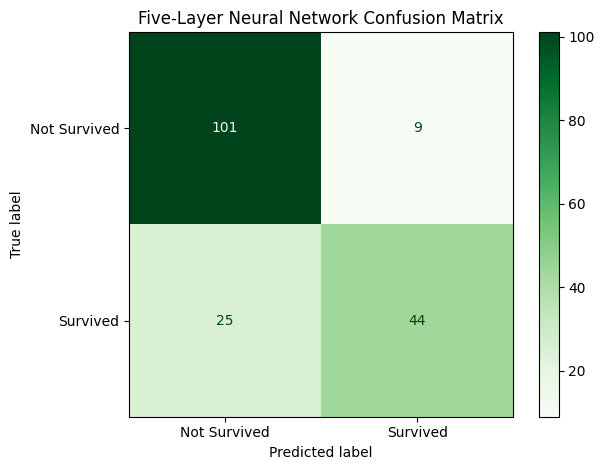

In [12]:
# =========================
# 10. 评估五层神经网络
# =========================

# 计算测试损失和测试准确率
test_loss_5, test_accuracy_5 = (
    model_5_layers.evaluate(
        X_test_scaled,
        y_test_array,
        verbose=0
    )
)


# 预测生还概率
test_probabilities_5 = (
    model_5_layers.predict(
        X_test_scaled,
        verbose=0
    ).ravel()
)


# 使用 0.5 作为分类阈值
test_predictions_5 = (
    test_probabilities_5 >= 0.5
).astype("int32")


# 计算评估指标
precision_5 = precision_score(
    y_test_integer,
    test_predictions_5
)

recall_5 = recall_score(
    y_test_integer,
    test_predictions_5
)

f1_5 = f1_score(
    y_test_integer,
    test_predictions_5
)


# 输出结果
print("Five-Layer Model Test Results")
print("--------------------------------")

print(f"Test Loss: {test_loss_5:.4f}")
print(
    f"Test Accuracy: "
    f"{test_accuracy_5 * 100:.2f}%"
)
print(f"Precision: {precision_5:.4f}")
print(f"Recall: {recall_5:.4f}")
print(f"F1 Score: {f1_5:.4f}")


# 分类报告
print("\nClassification Report:\n")

print(
    classification_report(
        y_test_integer,
        test_predictions_5,
        target_names=[
            "Not Survived",
            "Survived"
        ],
        digits=4,
        zero_division=0
    )
)


# 绘制混淆矩阵
ConfusionMatrixDisplay.from_predictions(
    y_test_integer,
    test_predictions_5,
    display_labels=[
        "Not Survived",
        "Survived"
    ],
    cmap="Greens",
    values_format="d"
)

plt.title(
    "Five-Layer Neural Network Confusion Matrix"
)

plt.tight_layout()
plt.show()

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,Test Loss
0,3-Layer Neural Network,0.8101,0.8571,0.6087,0.7119,0.4614
1,5-Layer Neural Network,0.8101,0.8302,0.6377,0.7213,0.4560


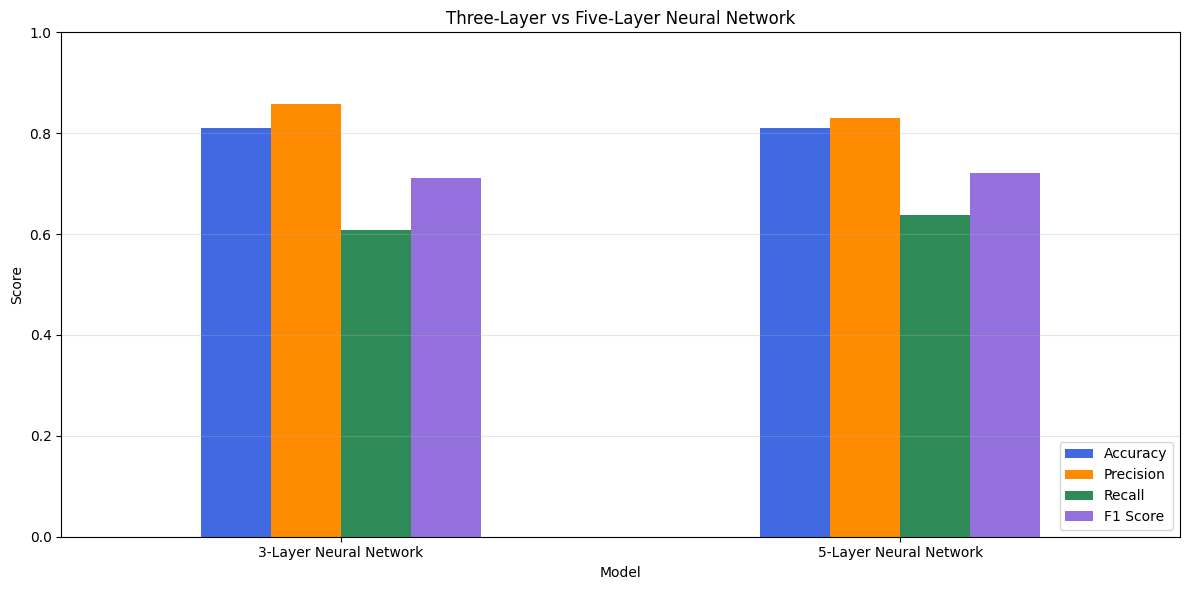


Best model by Accuracy: 3-Layer Neural Network
Best Accuracy: 81.01%

Best model by F1 Score: 5-Layer Neural Network
Best F1 Score: 0.7213


In [13]:
# =========================
# 11. 比较三层和五层模型
# =========================

comparison_df = pd.DataFrame(
    {
        "Model": [
            "3-Layer Neural Network",
            "5-Layer Neural Network"
        ],
        "Accuracy": [
            test_accuracy_3,
            test_accuracy_5
        ],
        "Precision": [
            precision_3,
            precision_5
        ],
        "Recall": [
            recall_3,
            recall_5
        ],
        "F1 Score": [
            f1_3,
            f1_5
        ],
        "Test Loss": [
            test_loss_3,
            test_loss_5
        ]
    }
)


# 显示四位小数的比较表
print("Model Comparison:")
display(
    comparison_df.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1 Score": "{:.4f}",
            "Test Loss": "{:.4f}"
        }
    )
)


# -------------------------
# 绘制比较图
# -------------------------

comparison_plot = (
    comparison_df
    .set_index("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ]
    ]
)


comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color=[
        "royalblue",
        "darkorange",
        "seagreen",
        "mediumpurple"
    ]
)

plt.title(
    "Three-Layer vs Five-Layer Neural Network"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# -------------------------
# 找出表现最好的模型
# -------------------------

best_accuracy_row = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

best_f1_row = comparison_df.loc[
    comparison_df["F1 Score"].idxmax()
]


print(
    "\nBest model by Accuracy:",
    best_accuracy_row["Model"]
)

print(
    f"Best Accuracy: "
    f"{best_accuracy_row['Accuracy'] * 100:.2f}%"
)

print(
    "\nBest model by F1 Score:",
    best_f1_row["Model"]
)

print(
    f"Best F1 Score: "
    f"{best_f1_row['F1 Score']:.4f}"
)

In [14]:
# =========================
# 12. 保存并验证五层模型
# =========================

# 保存最佳五层模型
model_5_layers.save(
    MODEL_5_FILENAME
)

print(
    f"Five-layer model saved: "
    f"{MODEL_5_FILENAME}"
)


# 计算文件大小
model_5_size_mb = (
    os.path.getsize(MODEL_5_FILENAME)
    / (1024 * 1024)
)

print(
    f"Model file size: "
    f"{model_5_size_mb:.2f} MB"
)


# -------------------------
# 重新加载并验证
# -------------------------

loaded_model_5 = (
    tf.keras.models.load_model(
        MODEL_5_FILENAME
    )
)


loaded_loss_5, loaded_accuracy_5 = (
    loaded_model_5.evaluate(
        X_test_scaled,
        y_test_array,
        verbose=0
    )
)


print("\nReloaded five-layer model verification:")

print(
    f"Test Loss: "
    f"{loaded_loss_5:.4f}"
)

print(
    f"Test Accuracy: "
    f"{loaded_accuracy_5 * 100:.2f}%"
)

Five-layer model saved: model_5_layers.h5
Model file size: 0.08 MB

Reloaded five-layer model verification:
Test Loss: 0.4560
Test Accuracy: 81.01%
